# Validate platform simulations: layer-wise firing rates

Stages the simulation files of a `SimulationCampaign` from entitycore (without staging the full circuit) and computes firing rates for each layer-wise node set (e.g. `Layer1Excitatory`, `L23Inhibitory`, ...) over a configurable time window.

Only a minimal slice of the circuit is downloaded (`circuit_config.json`, `node_sets.json` and the `nodes.h5` file of each population) so that node-set definitions can be resolved to concrete node ids.  Edges, morphologies and emodels are **not** downloaded.

## 1. Configuration

In [1]:
# Simulation campaign to validate
SIMULATION_CAMPAIGN_ID = "94580baf-fb99-4ebd-bf23-696f51e26ef4"

# Firing rate window [ms]
START_TIME_MS = 250.0
END_TIME_MS = 1000.0

# Pattern matching layer-wise node set names (Layer1Excitatory, L23Inhibitory, L5_EXC, ...)
LAYER_NODE_SET_REGEX = r"^(Layer|L)\d+[_-]?(Excitatory|Inhibitory|EXC|INH|Exc|Inh|E|I)$"

# Specific node sets to drop even if they match the regex
EXCLUDE_NODE_SETS: set[str] = {"Layer3Excitatory"}

# Restrict every layer-wise node set to the intersection with this node set
# (set to None to disable the restriction)
RESTRICT_NODE_SET = "hex0"

# Where to cache staged files
from pathlib import Path
STAGING_ROOT = Path("./staging") / SIMULATION_CAMPAIGN_ID
STAGING_ROOT.mkdir(parents=True, exist_ok=True)

## 2. Imports and authentication

In [2]:
import json
import re

import h5py
import libsonata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import obi_one as obi
from entitysdk import Client, ProjectContext
from entitysdk.models import (
    Circuit,
    Simulation,
    SimulationCampaign,
    SimulationExecution,
    SimulationResult,
)
from entitysdk.staging.simulation import stage_simulation
from entitysdk.staging.simulation_result import stage_simulation_result
from entitysdk.types import FetchFileStrategy
from obi_auth import get_token

In [3]:
token = get_token(environment="staging")
project_context = ProjectContext(
    virtual_lab_id=obi.LAB_ID_STAGING_TEST,
    project_id=obi.PROJECT_ID_STAGING_TEST,
)
db_client = Client(
    api_url="https://staging.openbraininstitute.org/api/entitycore",
    project_context=project_context,
    token_manager=token,
)

## 3. Fetch the simulation campaign metadata

In [ ]:
campaign = db_client.get_entity(
    entity_id=SIMULATION_CAMPAIGN_ID, entity_type=SimulationCampaign
)
print(f"Campaign: {campaign.name} ({campaign.id})")
print(f"  Circuit entity id: {campaign.entity_id}")
print(f"  #Simulations:     {len(campaign.simulations)}")

# Download the campaign_generation_config asset (the obi-one scan config JSON)
campaign_gen_asset = next(
    (a for a in campaign.assets if a.label.value == "campaign_generation_config"),
    None,
)
if campaign_gen_asset is None:
    labels = sorted({a.label.value for a in campaign.assets})
    raise RuntimeError(
        f"No 'campaign_generation_config' asset on campaign {campaign.id}. "
        f"Available asset labels: {labels}"
    )

campaign_gen_config_path = STAGING_ROOT / "campaign_generation_config.json"
if not campaign_gen_config_path.exists():
    db_client.fetch_file(
        entity_id=campaign.id,
        entity_type=SimulationCampaign,
        asset_id=campaign_gen_asset.id,
        output_path=campaign_gen_config_path,
        strategy=FetchFileStrategy.link_or_download,
    )
with campaign_gen_config_path.open() as fh:
    campaign_gen_config = json.load(fh)
print(f"\nDownloaded campaign_generation_config -> {campaign_gen_config_path}")

## 4. Fetch a minimal slice of the circuit

Only `circuit_config.json`, the `node_sets.json` and the `nodes.h5` file(s) are downloaded.  The sonata_circuit directory asset is **not** fully staged.

In [5]:
circuit_entity = db_client.get_entity(entity_id=campaign.entity_id, entity_type=Circuit)
circuit_dir_asset = next(
    a for a in circuit_entity.assets
    if a.is_directory and a.label.value == "sonata_circuit"
)

circuit_dir = (STAGING_ROOT / "circuit_partial").resolve()
circuit_dir.mkdir(parents=True, exist_ok=True)


def _fetch_from_circuit(remote_path: Path, local_path: Path) -> Path:
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if local_path.exists():
        return local_path
    return db_client.fetch_file(
        entity_id=circuit_entity.id,
        entity_type=Circuit,
        asset_id=circuit_dir_asset.id,
        output_path=local_path,
        asset_path=remote_path,
        strategy=FetchFileStrategy.link_or_download,
    )


circuit_config_path = _fetch_from_circuit(
    remote_path=Path("circuit_config.json"),
    local_path=circuit_dir / "circuit_config.json",
)
print(f"Fetched: {circuit_config_path}")

# Parse to discover referenced node_sets and nodes files (libsonata resolves the manifest)
circuit_cfg = libsonata.CircuitConfig.from_file(circuit_config_path)

node_sets_local = Path(circuit_cfg.node_sets_path)
_fetch_from_circuit(
    remote_path=node_sets_local.relative_to(circuit_dir),
    local_path=node_sets_local,
)
print(f"Fetched: {node_sets_local}")

nodes_files: set[Path] = set()
for pop_name in circuit_cfg.node_populations:
    nodes_files.add(Path(circuit_cfg.node_population_properties(pop_name).elements_path))

for nf in nodes_files:
    _fetch_from_circuit(remote_path=nf.relative_to(circuit_dir), local_path=nf)
    print(f"Fetched: {nf} ({nf.stat().st_size / 1e6:.1f} MB)")

[2026-04-20 12:51:59,414] INFO: HTTP Request: GET https://staging.openbraininstitute.org/api/entitycore/circuit/0f25396a-1c16-43d7-9943-43e78f84e1ed "HTTP/1.1 200 OK"
Fetched: /Users/james/Documents/obi/code/obi-main/obi-one/projects/platform_simulation_validation/staging/94580baf-fb99-4ebd-bf23-696f51e26ef4/circuit_partial/circuit_config.json
Fetched: /Users/james/Documents/obi/code/obi-main/obi-one/projects/platform_simulation_validation/staging/94580baf-fb99-4ebd-bf23-696f51e26ef4/circuit_partial/node_sets.json
Fetched: /Users/james/Documents/obi/code/obi-main/obi-one/projects/platform_simulation_validation/staging/94580baf-fb99-4ebd-bf23-696f51e26ef4/circuit_partial/nodes_external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical.h5 (37.4 MB)
Fetched: /Users/james/Documents/obi/code/obi-main/obi-one/projects/platform_simulation_validation/staging/94580baf-fb99-4ebd-bf23-696f51e26ef4/circuit_partial/S1nonbarrel_neurons/nodes.h5 (54.3 MB)
Fetched: /Users/james/Documents/obi/code/obi

## 5. Stage all simulations and their results

Only the simulation config, the custom node-set file and the spike report are downloaded.  The circuit is **not** re-staged; we point `stage_simulation` at the partial `circuit_config.json` fetched above.

In [6]:
simulations_root = STAGING_ROOT / "simulations"
simulations_root.mkdir(parents=True, exist_ok=True)

staged = []  # [{sim_id, name, sim_config_path, params}]
for sim_ref in campaign.simulations:
    simulation = db_client.get_entity(entity_id=sim_ref.id, entity_type=Simulation)
    sim_dir = simulations_root / simulation.name.replace(" ", "_").lower()

    sim_config_path = sim_dir / "simulation_config.json"
    if not sim_config_path.exists():
        sim_config_path = stage_simulation(
            client=db_client,
            model=simulation,
            output_dir=sim_dir,
            circuit_config_path=circuit_config_path,
        )

    # Download spikes.h5 via the corresponding SimulationResult (skip if already on disk)
    with sim_config_path.open() as fh:
        _sim_cfg = json.load(fh)
    _spikes_file = (
        sim_dir / _sim_cfg["output"]["output_dir"] / _sim_cfg["output"]["spikes_file"]
    )
    if not _spikes_file.exists():
        executions = db_client.search_entity(
            entity_type=SimulationExecution, query={"used__id": simulation.id}
        ).all()
        if not executions:
            print(f"WARNING: no SimulationExecution for '{simulation.name}' ({simulation.id})")
            continue
        sim_result = db_client.get_entity(
            entity_id=executions[0].generated[0].id, entity_type=SimulationResult
        )
        stage_simulation_result(
            client=db_client,
            model=sim_result,
            output_dir=sim_dir,
            simulation_config_file=sim_config_path,
        )

    staged.append(
        {
            "simulation_id": str(simulation.id),
            "name": simulation.name,
            "sim_config_path": sim_config_path,
            "params": simulation.scan_parameters or {},
        }
    )
    print(f"Staged '{simulation.name}' -> {sim_config_path}")

print(f"\nStaged {len(staged)} simulation(s).")

[2026-04-20 12:51:59,825] INFO: HTTP Request: GET https://staging.openbraininstitute.org/api/entitycore/simulation/369d4e59-ce5e-4980-a464-1bff24f732ec "HTTP/1.1 200 OK"
Staged 'Simulation 0' -> staging/94580baf-fb99-4ebd-bf23-696f51e26ef4/simulations/simulation_0/simulation_config.json

Staged 1 simulation(s).


## 6. Identify layer-wise node sets and resolve their node ids

Any node set whose name matches `LAYER_NODE_SET_REGEX` (e.g. `Layer1Excitatory`, `L23Inhibitory`) is kept.  Resolution goes through `libsonata.NodeSets.materialize()`, then every set is intersected with `RESTRICT_NODE_SET` (e.g. `hex0`) so only neurons inside the central column contribute.

In [7]:
node_sets = libsonata.NodeSets.from_file(node_sets_local)
layer_regex = re.compile(LAYER_NODE_SET_REGEX)
layer_node_set_names = sorted(
    n for n in node_sets.names
    if layer_regex.match(n) and n not in EXCLUDE_NODE_SETS
)

print(f"Found {len(layer_node_set_names)} layer-wise node set(s):")
for n in layer_node_set_names:
    print(f"  - {n}")
if EXCLUDE_NODE_SETS:
    print(f"Excluded by EXCLUDE_NODE_SETS: {sorted(EXCLUDE_NODE_SETS)}")
if not layer_node_set_names:
    print(
        f"\n(No match with regex {LAYER_NODE_SET_REGEX!r}. "
        f"All node sets: {sorted(node_sets.names)})"
    )

Found 10 layer-wise node set(s):
  - Layer1Inhibitory
  - Layer23Excitatory
  - Layer23Inhibitory
  - Layer2Excitatory
  - Layer4Excitatory
  - Layer4Inhibitory
  - Layer5Excitatory
  - Layer5Inhibitory
  - Layer6Excitatory
  - Layer6Inhibitory
Excluded by EXCLUDE_NODE_SETS: ['Layer3Excitatory']


In [8]:
# Open every node population referenced by the circuit so NodeSets.materialize() can resolve criteria
node_populations: dict[str, libsonata.NodePopulation] = {}
for nf in nodes_files:
    store = libsonata.NodeStorage(nf)
    for pop_name in store.population_names:
        node_populations[pop_name] = store.open_population(pop_name)
print(f"Node populations: {list(node_populations)}")


def _materialize(ns_name: str) -> dict[str, np.ndarray]:
    """Return {population_name: np.ndarray of node ids} for a node set."""
    per_pop: dict[str, np.ndarray] = {}
    for pop_name, pop in node_populations.items():
        try:
            sel = node_sets.materialize(ns_name, pop)
        except Exception:
            continue  # node set not applicable to this population
        ids = sel.flatten().astype(np.int64)
        if ids.size > 0:
            per_pop[pop_name] = ids
    return per_pop


# Optional restriction node set (e.g. hex0) applied to every layer-wise set
restrict_ids: dict[str, np.ndarray] = {}
if RESTRICT_NODE_SET:
    if RESTRICT_NODE_SET not in node_sets.names:
        raise KeyError(
            f"Restriction node set '{RESTRICT_NODE_SET}' not found. "
            f"Available: {sorted(node_sets.names)[:10]}..."
        )
    restrict_ids = _materialize(RESTRICT_NODE_SET)
    total = sum(v.size for v in restrict_ids.values())
    print(f"Restriction '{RESTRICT_NODE_SET}': {total} neurons")

# node_set_name -> {population_name -> np.ndarray of node ids}
node_set_ids: dict[str, dict[str, np.ndarray]] = {}
for ns_name in layer_node_set_names:
    per_pop = _materialize(ns_name)
    if restrict_ids:
        per_pop = {
            pop: np.intersect1d(ids, restrict_ids.get(pop, np.array([], dtype=np.int64)))
            for pop, ids in per_pop.items()
        }
        per_pop = {pop: ids for pop, ids in per_pop.items() if ids.size > 0}
    node_set_ids[ns_name] = per_pop
    total = sum(v.size for v in per_pop.values())
    print(f"  {ns_name}: {total} neurons across {len(per_pop)} population(s)")

Node populations: ['external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical', 'S1nonbarrel_neurons', 'VPM', 'POm']
Restriction 'hex0': 30190 neurons
  Layer1Inhibitory: 291 neurons across 1 population(s)
  Layer23Excitatory: 7179 neurons across 1 population(s)
  Layer23Inhibitory: 994 neurons across 1 population(s)
  Layer2Excitatory: 3101 neurons across 1 population(s)
  Layer4Excitatory: 4568 neurons across 1 population(s)
  Layer4Inhibitory: 302 neurons across 1 population(s)
  Layer5Excitatory: 4989 neurons across 1 population(s)
  Layer5Inhibitory: 835 neurons across 1 population(s)
  Layer6Excitatory: 10051 neurons across 1 population(s)
  Layer6Inhibitory: 981 neurons across 1 population(s)


## 7. Compute firing rates per simulation and node set

Firing rate = (# spikes in [START_TIME_MS, END_TIME_MS] from neurons in the node set) / (# neurons in the set × window duration in seconds).

In [9]:
def _read_spikes(spikes_file: Path) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    """Return {population_name: (node_ids, timestamps_ms)} for all spiking populations."""
    out: dict[str, tuple[np.ndarray, np.ndarray]] = {}
    with h5py.File(spikes_file, "r") as h5:
        for pop_name, pop_grp in h5["spikes"].items():
            out[pop_name] = (pop_grp["node_ids"][:], pop_grp["timestamps"][:])
    return out


def _firing_rate_for_set(
    pop_spikes: dict[str, tuple[np.ndarray, np.ndarray]],
    per_pop_ids: dict[str, np.ndarray],
    t_start: float,
    t_stop: float,
) -> tuple[int, int, float]:
    """Return (n_cells, n_spikes, firing_rate_hz) summed across all populations in the set."""
    duration_s = (t_stop - t_start) / 1_000.0
    n_cells = sum(int(ids.size) for ids in per_pop_ids.values())
    n_spikes = 0
    for pop_name, ids in per_pop_ids.items():
        if pop_name not in pop_spikes:
            continue
        nids, ts = pop_spikes[pop_name]
        mask = (ts >= t_start) & (ts < t_stop) & np.isin(nids, ids)
        n_spikes += int(mask.sum())
    rate = n_spikes / (n_cells * duration_s) if n_cells > 0 and duration_s > 0 else float("nan")
    return n_cells, n_spikes, rate

In [10]:
rows: list[dict] = []
for entry in staged:
    sim_config_path: Path = entry["sim_config_path"]
    sim_dir = sim_config_path.parent
    with sim_config_path.open() as fh:
        sim_cfg = json.load(fh)

    spikes_file = (
        sim_dir / sim_cfg["output"]["output_dir"] / sim_cfg["output"]["spikes_file"]
    )
    pop_spikes = _read_spikes(spikes_file)

    for ns_name, per_pop in node_set_ids.items():
        if not per_pop:
            continue
        n_cells, n_spikes, rate = _firing_rate_for_set(
            pop_spikes, per_pop, START_TIME_MS, END_TIME_MS
        )
        rows.append(
            {
                "simulation_id": entry["simulation_id"],
                "simulation_name": entry["name"],
                "node_set": ns_name,
                "n_cells": n_cells,
                "n_spikes": n_spikes,
                "firing_rate_hz": rate,
            }
        )

firing_rates = pd.DataFrame(rows)

# Keep node_set order stable by using the order we discovered in section 6
if not firing_rates.empty:
    firing_rates["node_set"] = pd.Categorical(
        firing_rates["node_set"], categories=layer_node_set_names, ordered=True
    )
    firing_rates = firing_rates.sort_values(["simulation_name", "node_set"]).reset_index(
        drop=True
    )

firing_rates

,simulation_id,simulation_name,node_set,n_cells,n_spikes,firing_rate_hz
0,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer1Inhibitory,291,106,0.485682
1,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer23Excitatory,7179,301,0.055904
2,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer23Inhibitory,994,175,0.234742
3,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer2Excitatory,3101,136,0.058476
4,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer4Excitatory,4568,661,0.192936
5,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer4Inhibitory,302,94,0.415011
6,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer5Excitatory,4989,1160,0.310015
7,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer5Inhibitory,835,471,0.752096
8,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer6Excitatory,10051,609,0.080788
9,369d4e59-ce5e-4980-a464-1bff24f732ec,Simulation 0,Layer6Inhibitory,981,235,0.319402


## 8. Plot firing rates per node set (one line per simulation)

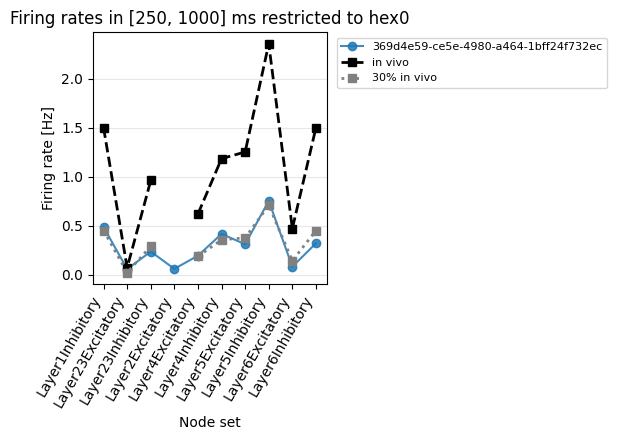

In [ ]:
# In vivo reference firing rates [Hz] (keyed by canonical "L{layer}_{EXC|INH}")
VIVO_FRS = {
    "L1_INH": 1.5,
    "L23_EXC": 0.07,
    "L23_INH": 0.961,
    "L4_EXC": 0.619,
    "L4_INH": 1.184,
    "L5_EXC": 1.252,
    "L5_INH": 2.357,
    "L6_EXC": 0.47,
    "L6_INH": 1.5,
}


def _vivo_key(node_set_name: str) -> str | None:
    m = re.match(
        r"^(?:Layer|L)(\d+)[_-]?(Excitatory|Inhibitory|EXC|INH|Exc|Inh|E|I)$",
        node_set_name,
    )
    if not m:
        return None
    ei = m.group(2).upper()
    ei_short = "EXC" if ei in {"EXC", "EXCITATORY", "E"} else "INH"
    return f"L{m.group(1)}_{ei_short}"


if firing_rates.empty:
    print("No firing-rate rows to plot.")
else:
    pivot = firing_rates.pivot_table(
        index="node_set",
        columns="simulation_id",
        values="firing_rate_hz",
        observed=True,
    ).reindex(layer_node_set_names)

    vivo_series = pd.Series(
        [VIVO_FRS.get(_vivo_key(n) or "", np.nan) for n in layer_node_set_names],
        index=layer_node_set_names,
        dtype="float64",
    )

    fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(pivot)), 4.5))
    pivot.plot(ax=ax, marker="o", alpha=0.85)
    x = np.arange(len(layer_node_set_names))
    # ax.plot(
    #     x, vivo_series.values,
    #     marker="s", linestyle="--", color="black", linewidth=2, label="in vivo",
    # )
    ax.plot(
        x, (vivo_series * 0.3).values,
        marker="s", linestyle=":", color="gray", linewidth=2, label="30% in vivo",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(layer_node_set_names, rotation=60, ha="right")
    ax.set_ylabel("Firing rate [Hz]")
    ax.set_xlabel("Node set")
    restriction = f" restricted to {RESTRICT_NODE_SET}" if RESTRICT_NODE_SET else ""
    ax.set_title(
        f"Firing rates in [{START_TIME_MS:.0f}, {END_TIME_MS:.0f}] ms{restriction}"
    )
    ax.grid(axis="y", alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()